In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cooler
import bioframe
import bbi
import matplotlib as mpl
mpl.style.use('seaborn-white')
import os
from matplotlib_venn import venn2
from pandas.api.types import CategoricalDtype

/tmp/ipykernel_32984/2465270403.py:10: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  mpl.style.use('seaborn-white')


In [2]:
# make matplotlib pdf-s text recognizable by evil-Adobe
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [3]:
def normalize_shoulder(bds,subtract,cond):  
    #print("Hello")
    binsize=10000
    flank = 100000
    AsyncBounds = bds
    #print(bds.head())
    mids = (AsyncBounds['start'] + AsyncBounds['end']) // 2
    nbins = flank*2 // binsize
    m=nbins//2
    bwfile = 'cooltools54/Insulation/10kb_bins_100kb_win/'+cond+'_10kb_bin_100kb_win_insulation.100000.bw'
    _ddd = bbi.stackup(bwfile, AsyncBounds['chrom'], mids - flank, mids + flank, bins=nbins)
    shoulders = np.hstack( [_ddd[:,:subtract], _ddd[:,-subtract:]] )
    shoulders = np.nanmean(shoulders, axis=1, keepdims=True)
    _ddd -= shoulders
    _ddd=bds.reindex(_ddd[:,m].argsort())
    return _ddd

In [4]:
df1 = pd.read_csv("Filtered-insul/OU-HiC-N6IPSC2-MN-W0_OU-HiC-N6IPSC2-MN-W6_weight_filtered.tsv",sep='\t').dropna(subset=['boundary_strength_100000_N6IPSC2-MN-W0'])
df1=df1[df1['boundary_strength_100000_N6IPSC2-MN-W0']>=0.1]
len(df1)

15353

In [5]:
df2 = pd.read_csv("Filtered-insul/OU-HiC-N6IPSC2-MN-W0_OU-HiC-N6IPSC2-MN-W6_weight_filtered.tsv",sep='\t').dropna(subset=['boundary_strength_100000_N6IPSC2-MN-W6'])
df2=df2[df2['boundary_strength_100000_N6IPSC2-MN-W6']>=0.1]
len(df2)

13007

In [6]:
df1_only=pd.read_csv("Filtered-insul/Insulation_regions/Only_(N6IPSC2-MN-W0_N6IPSC2-MN-W6)_W0regions",sep='\t')
common=pd.read_csv("Filtered-insul/Insulation_regions/Common_(N6IPSC2-MN-W0_N6IPSC2-MN-W6)_W0regions",sep='\t')
df2_only=pd.read_csv("Filtered-insul/Insulation_regions/Only_(N6IPSC2-MN-W0_N6IPSC2-MN-W6)_W6regions",sep='\t')
print(len(df1_only),len(common),len(df2_only))

7109 7073 5115


In [7]:
ex=['chrX','chrY','chrM']
df1_only = df1_only[~df1_only['chrom'].isin(ex)][['chrom','start','end']].reset_index(drop=True)
df1_only=normalize_shoulder(df1_only,3,'OU-HiC-N6IPSC2-MN-W0')

common=common[~common['chrom'].isin(ex)][['chrom','start','end']].reset_index(drop=True)
common=normalize_shoulder(common,3,'OU-HiC-N6IPSC2-MN-W0')

df2_only=df2_only[~df2_only['chrom'].isin(ex)][['chrom','start','end']].reset_index(drop=True)
df2_only=normalize_shoulder(df2_only,3,'OU-HiC-N6IPSC2-MN-W6')

print(len(df1_only),len(common),len(df2_only))

7109 7073 5115


In [8]:
union_df=pd.concat([df1_only, common, df2_only], ignore_index=True)
len(union_df)

19297

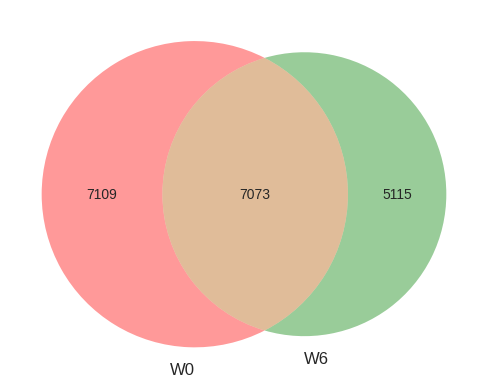

In [2]:
venn2(subsets = (7109, 5115, 7073), set_labels = ('W0', 'W6'))
#plt.savefig("Plots/VennDiagram-WO-W6.pdf")

In [13]:
#N6
#conditions=["OU-HiC-N6-pfib-D4","OU-HiC-N6IPSC1-R1","OU-HiC-N6IPSC2-R1","OU-HiC-N6IPSC1MND45-R2","OU-HiC-N6IPSC2MND45-R2"]
#N9
#conditions=["OU-HiC-N9-pfib-D4","OU-HiC-N9IPSC1-R2","OU-HiC-N9IPSC2-R1","OU-HiC-N9IPSC1MND45-R2","OU-HiC-N9IPSC2MND45-R2"]
#C2
#conditions=["OU-HiC-C2-pfib-D4","OU-HiC-C2IPSC2-R1","OU-HiC-C2IPSC1-R1","OU-HiC-C2IPSC1MND45-R1","OU-HiC-C2IPSC2MND45-R1"]
#C3
#conditions=["OU-HiC-C3-pfib-D4","OU-HiC-C3IPSC3-R2","OU-HiC-C3IPSC4-R1","OU-HiC-C3IPSC3MND45-R1","OU-HiC-C3IPSC4MND45-R1"]
#timecourse N6
#conditions=["OU-HiC-N6-pfib-D4","OU-HiC-N6IPSC2-R1","OU-HiC-N6IPSC2-EP-W0",
#           "OU-HiC-N6IPSC2-MN-W0","OU-HiC-N6IPSC2-MN-W3","OU-HiC-N6IPSC2-MN-W6"]
#timecourse N9
conditions=["OU-HiC-N9-pfib-D4","OU-HiC-N9IPSC2-R1","OU-HiC-N9IPSC2-EP-W0",
            "OU-HiC-N9IPSC2-MN-W0","OU-HiC-N9IPSC2-MN-W3","OU-HiC-N9IPSC2-MN-W6"]

/tmp/ipykernel_14037/3739528917.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('coolwarm')
/tmp/ipykernel_14037/3739528917.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('coolwarm')
/tmp/ipykernel_14037/3739528917.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('coolwarm')
/tmp/ipykernel_14037/3739528917.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3

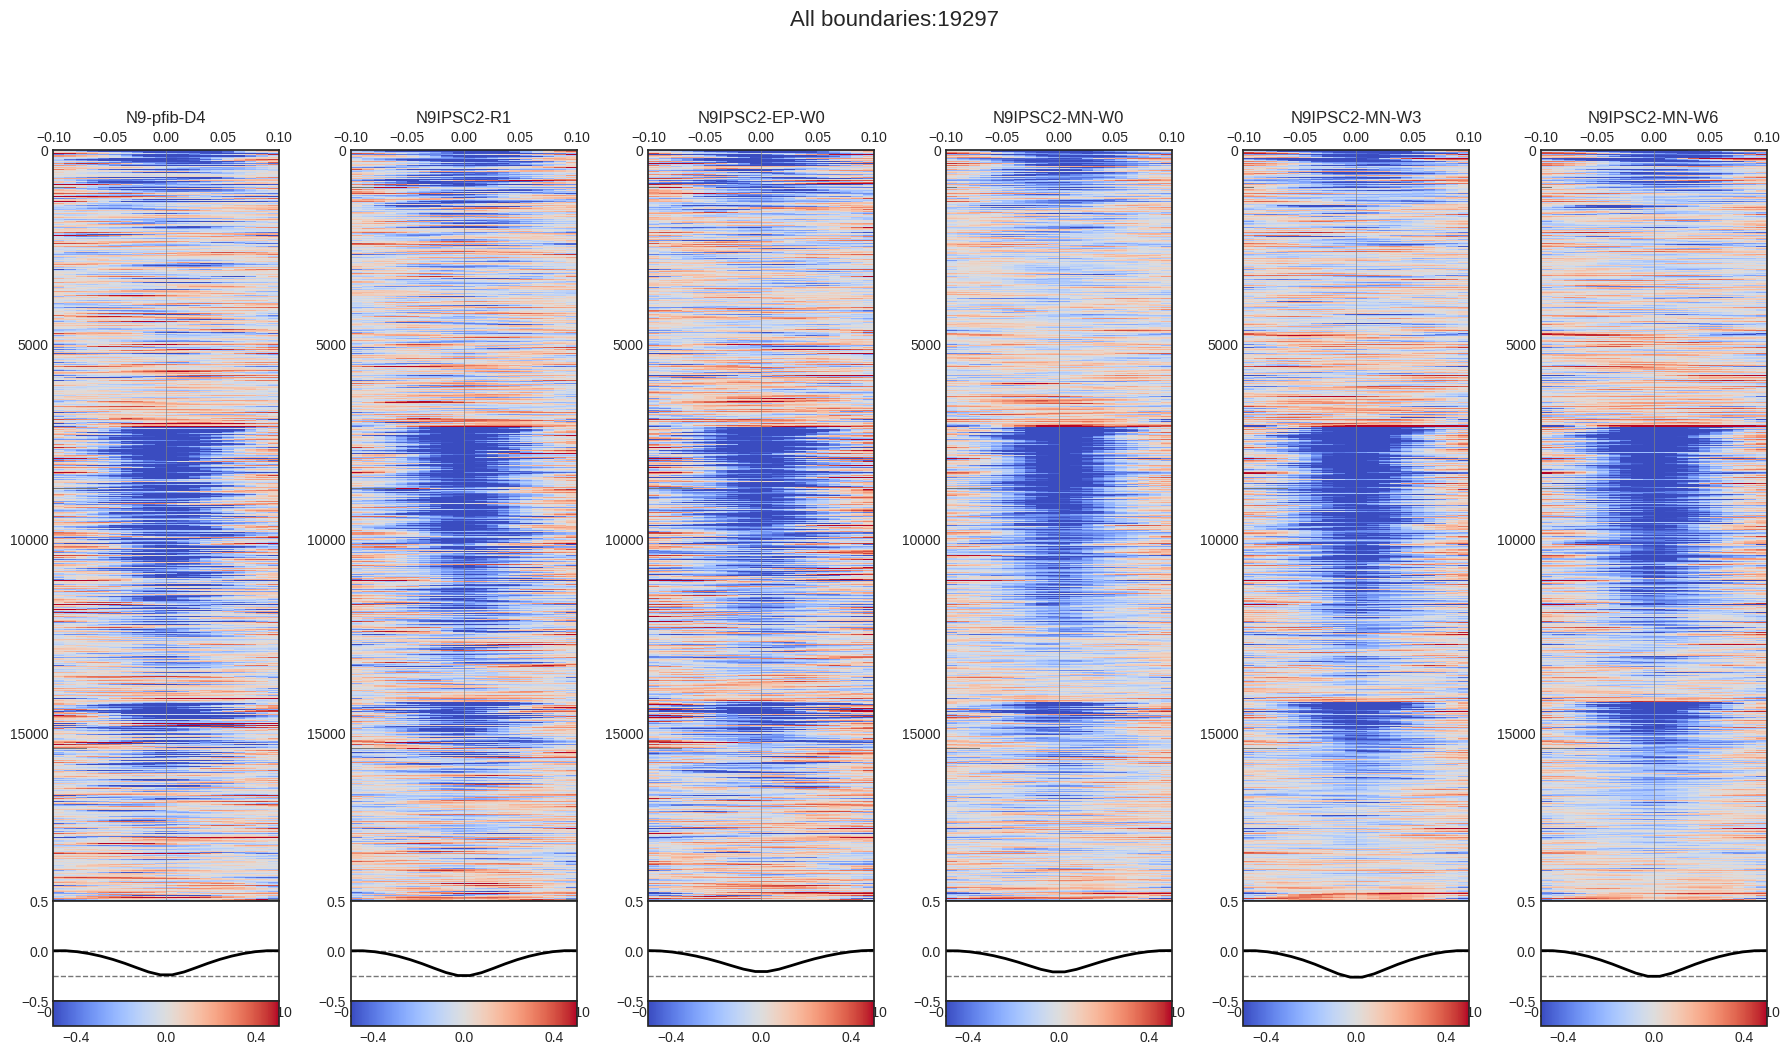

In [14]:
gsIns = plt.GridSpec(nrows=3, ncols=len(conditions), 
              height_ratios=[15, 2, 0.5], 
              hspace=0)
plt.figure(figsize=(3*len(conditions), 10))
binsize=10000

stacks = {}
for i, cond in enumerate(conditions):
    bd = union_df
    AsyncBounds = bd
    mids = (AsyncBounds['start'] + AsyncBounds['end']) // 2
    #print(len(mids))
    flank = 100000
    nbins = flank*2 // binsize
    bwfile = 'cooltools54/Insulation/10kb_bins_100kb_win/'+cond+'_10kb_bin_100kb_win_insulation.100000.bw'
    stacks[cond] = bbi.stackup(bwfile, AsyncBounds['chrom'], mids - flank, mids + flank, bins=nbins)
    
    #normalize
    _ddd=stacks[cond]
    shoulders = np.hstack( [_ddd[:,:3], _ddd[:,-3:]] )
    shoulders = np.nanmean(shoulders, axis=1, keepdims=True)
    _ddd -= shoulders
    stacks[cond]=_ddd
    
    #X = stacks['hTERT-TP2-R1']
    #idx = np.argsort(X[:, X.shape[1]//2])
    x = np.linspace(-flank/1e6, flank/1e6, nbins)
    cmap = plt.cm.get_cmap('coolwarm')
    cmap.set_bad('#777777')
    im_opts = dict(
        vmin=-0.5, 
        vmax=0.5,
        extent=[-flank/1e6, flank/1e6, len(AsyncBounds), 0],
        cmap=cmap
    )
    # heatmap
    ax = ax1 = plt.subplot(gsIns[0, i])
    X = stacks[cond]
    #idx = np.argsort(X[:, X.shape[1]//2])
    #print(idx)
    img = ax.matshow(X, **im_opts, rasterized=True)
    ax.axvline(0, c='grey', lw=0.5)
    ax.grid(False)
    ax.set_aspect('auto')
    ax.set_title(cond.replace("OU-HiC-",""))
    #if i > 0:
    #    ax.yaxis.set_visible(False)
    
    # summary
    ax = plt.subplot(gsIns[1, i], sharex=ax1)    
    ax.axhline(0, c='#777777', lw=1, ls='--')
    ax.axhline(-0.25, c='#777777', lw=1, ls='--')
    ax.plot(x, np.nanmean(stacks[cond], axis=0), c='k', lw=2)
    ax.set_xlim(-flank/1e6, flank/1e6)
    ax.xaxis.set_visible(True)
    ax.set_ylim(-0.5, 0.5)
    #if i > 0:
       #ax.yaxis.set_visible(False)
    
    # color bar
    cax = plt.subplot(gsIns[2, i])
    cb = plt.colorbar(img, cax=cax, orientation='horizontal')
    cb.locator = mpl.ticker.MaxNLocator(nbins=3)
    cb.update_ticks()
    
plt.suptitle("All boundaries"+":"+str(len(bd)),fontsize=16,x=0.5,y=1.05)    
plt.tight_layout()
plt.savefig("GitHub/Plots/TimeCourseN9_(N6IPSC2-MN-W0_N6IPSC2-MN-W6)_union.pdf",bbox_inches = 'tight')

In [15]:
'''timeColors = {
  "OU-HiC-N6-pfib-D4": "red",
  "OU-HiC-N6IPSC1-R1":"lightblue",
  "OU-HiC-N6IPSC2-R1":"blue",
  "OU-HiC-N6IPSC1MND45-R2":"lightgreen",
  "OU-HiC-N6IPSC2MND45-R2":"darkgreen"   
}

timeColors = {
  "OU-HiC-N9-pfib-D4": "red",
  "OU-HiC-N9IPSC1-R2":"lightblue",
  "OU-HiC-N9IPSC2-R1":"blue",
  "OU-HiC-N9IPSC1MND45-R2":"lightgreen",
  "OU-HiC-N9IPSC2MND45-R2":"darkgreen"
    
}
timeColors = {
  "OU-HiC-C2-pfib-D4": "red",
  "OU-HiC-C2IPSC2-R1":"lightblue",
  "OU-HiC-C2IPSC1-R1":"blue",
  "OU-HiC-C2IPSC1MND45-R1":"lightgreen",
  "OU-HiC-C2IPSC2MND45-R1":"darkgreen"
    
}
timeColors = {
  "OU-HiC-C3-pfib-D4": "red",
  "OU-HiC-C3IPSC3-R2":"lightblue",
  "OU-HiC-C3IPSC4-R1":"blue",
  "OU-HiC-C3IPSC3MND45-R1":"lightgreen",
  "OU-HiC-C3IPSC4MND45-R1":"darkgreen"  
}
'''
timeColors={"OU-HiC-N9-pfib-D4":"red","OU-HiC-N9IPSC2-R1":"salmon","OU-HiC-N9IPSC2-EP-W0":"brown",
            "OU-HiC-N9IPSC2-MN-W0":"blue","OU-HiC-N9IPSC2-MN-W3":"steelblue","OU-HiC-N9IPSC2-MN-W6":"darkblue"}
'''
timeColors={"OU-HiC-N6-pfib-D4":"red","OU-HiC-N6IPSC2-R1":"salmon","OU-HiC-N6IPSC2-EP-W0":"brown",
            "OU-HiC-N6IPSC2-MN-W0":"blue","OU-HiC-N6IPSC2-MN-W3":"steelblue","OU-HiC-N6IPSC2-MN-W6":"darkblue"}
'''

'\ntimeColors={"OU-HiC-N6-pfib-D4":"red","OU-HiC-N6IPSC2-R1":"salmon","OU-HiC-N6IPSC2-EP-W0":"brown",\n            "OU-HiC-N6IPSC2-MN-W0":"blue","OU-HiC-N6IPSC2-MN-W3":"steelblue","OU-HiC-N6IPSC2-MN-W6":"darkblue"}\n'

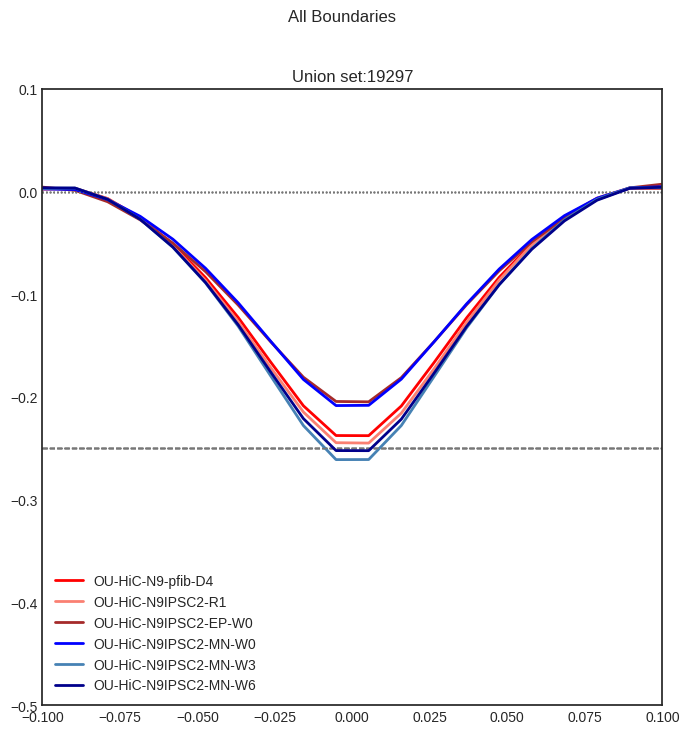

In [16]:
# Insulation
flank = 100000
binkb = 10000
nbins = flank*2 // binsize
x = np.linspace(-flank/1e6, flank/1e6, nbins)

#gsIns = plt.GridSpec(nrows=5, ncols=3)
plt.figure(figsize=(8,8))

#plt.subplot(gsIns[0])
for cond in conditions:
    plt.axhline(0, c='#777777', lw=1, ls=':')
    plt.axhline(-0.25, c='#777777', lw=1, ls='--')
    plt.plot(x, np.nanmean(stacks[cond], axis=0), lw=2,label = cond,color=timeColors[cond])
    plt.xlim(-flank/1e6, flank/1e6)
    plt.ylim(-0.5, 0.1)
    plt.legend()
    #plt.title('Intersected set') 
    #plt.title('Only W6 boundaries set') 
    plt.title('Union set:'+str(len(union_df)))
   
    
plt.suptitle('All Boundaries')
plt.savefig('GitHub/Plots/TimeCourseN9_(N6IPSC2-MN-W0_N6IPSC2-MN-W6)_union_pileup.pdf',bbox_inches = 'tight')